## Final analysis of 'good' radiogenic data
These files should be outputs from the long radiogenic data generated from the updated 
qpixg4 and qpixrtd code. The data format from the input ROOT files must follow this structure:
- TTree Entry:
-- int pix_x
-- int pix_y
-- double reset time
-- vector<int> hit_id
-- vector<int> hit_frq // used for identifying how many ids consituted this hit

In [1]:
import ROOT
import matplotlib.pyplot as plt
import numpy

Welcome to JupyROOT 6.27/01


In [3]:
inputfiles = "./hits/*root"
rdf = ROOT.RDataFrame("event_tree", inputfiles)
data = rdf.AsNumpy()
pix_x = data["pixel_x"]
pix_y = data["pixel_y"]
reset = data["pixel_reset"]
trkID = data["pixel_reset_truth_track_id"]
trkWt = data["pixel_reset_truth_weight"]

In [5]:
import numpy as np

# find the most active region
xMAX = 575 # from metadata tree, 11.979 tiles in this direction..
xMIN = 1
yMAX = 1500 # from metadata tree, 31.25 tiles in this direction..
yMIN = 1

# each asic is 4x4 channels
channelXdim = 4 # 6
channelYdim = 4 # 6

# each tile is 8x8 ASIC array
arrayXdim = 10 # 8
arrayYdim = 14 # 8

# scan through the detector volume
xDIM = arrayXdim * channelXdim
yDIM = arrayYdim * channelYdim
xITR = range(xMIN, xMAX, xDIM)
yITR = range(yMIN, yMAX, yDIM)

# lots of zero positions
bestPos = 0
bestX, bestY = 0, 0
for x in xITR:
    for y in yITR:
        xpos = np.logical_and(pix_x>=x, pix_x<x+xDIM)
        ypos = np.logical_and(pix_y>=y, pix_y<y+yDIM)
        sqpos = np.logical_and(xpos, ypos)
        nResets = np.count_nonzero(sqpos)
        if nResets > bestPos:
            bestPos = nResets
            bestX = x
            bestY = y

print(f"found most active position: ({bestX},{bestY}) with {bestPos} hits")

found most active position: (281,841) with 19158 hits


In [6]:
import pandas as pd

pd_data = {}
pd_data["pX"] = pix_x
pd_data["pY"] = pix_y
pd_data["Reset"] = reset
# data["Isotope"] = listIso

df = pd.DataFrame(pd_data)
# df["Isotope"] = df["Isotope"].map(str)

### create Asic numbers for this Tile columns using the pandas dataframe

In [28]:
from math import ceil

# count these as done in Simulation "Top Left" Asic is (0,0) : (row, col)
# create X
df['tileX'] = ((df['pX'] ) / xDIM).map(int)
df["AsicX"] = ((df["pX"] ) / channelXdim).map(int)

# create Y
df['tileY'] = ((df['pY'] ) / yDIM).map(int)
df["AsicY"] = ((df["pY"] ) / channelYdim).map(int)

# create N, unique ASIC / Tile numbers to easily histogram
df['tileN'] = df['tileX'] + df['tileY'] * ceil(xMAX / xDIM)
df['AsicN'] = df['AsicX'] + df['AsicY'] * ceil(xMAX / channelXdim)

# for each asic, it should only number a nPix within it's dimensions channelXdim *channelYdim
# we chose X-dim as the "row" and Y-dim as the "column", to be consistent with the 
# coordinates for the tile / simulation dimensions
npx = ((df["pX"]) - channelXdim*df["AsicX"] - 1).map(int)
npy = ((df["pY"]) - channelYdim*df["AsicY"] - 1).map(int)
df["nPix"] = npx + channelYdim*npy
df["PixN"] = df['pX'] + (df['pY'] ) * xMAX # include -1 since pY is one counted

#### Visualize total resets per tile

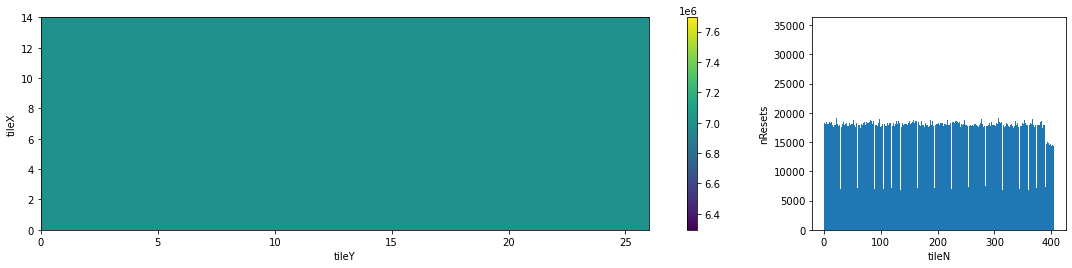

In [31]:
scale = 150
# view of tiles
x = df['tileX'].values
y = df['tileY'].values

fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})

h = ax[0].hist2d(y, x, bins=[(0, max(df['tileY'])), (0, max(df['tileX']) ) ])
ax[0].set_ylabel('tileX')
ax[0].set_xlabel("tileY")
fig.colorbar(h[3], ax=ax[0])

tiles = df['tileN'].values
ax[1].hist(tiles, bins=405, range=(0,405))
ax[1].set_xlabel('tileN')
ax[1].set_ylabel('nResets')
plt.tight_layout()
plt.savefig("TileHits_hits.pdf")

#### Visualize resets based on ASIC

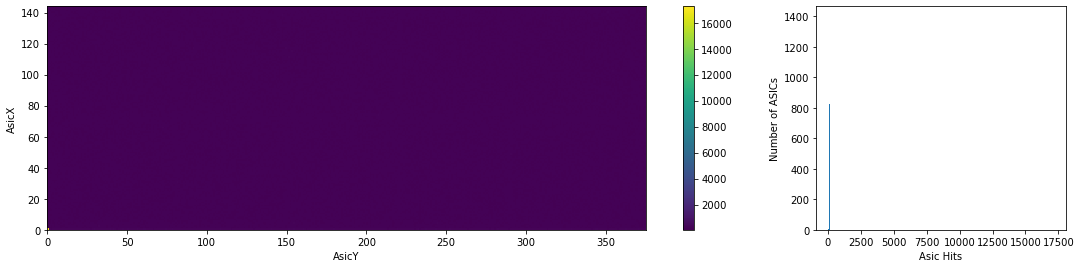

In [32]:
# view of asics
x = df['AsicX'].values
y = df['AsicY'].values

xZoom, yZoom =  1, 1

fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
# h = ax[0].hist2d(y, x, bins=[len(df['AsicY'].unique()), len(df['AsicX'].unique())])
h = ax[0].hist2d(y, x, bins=[int(yMAX/channelYdim/yZoom), int(xMAX/channelXdim/xZoom)], range=[[0, ceil(yMAX/channelYdim/yZoom)], [0, ceil(xMAX/channelXdim/xZoom)]])
ax[0].set_ylabel('AsicX')
ax[0].set_xlabel("AsicY")
fig.colorbar(h[3], ax=ax[0])

countAsics = df['AsicN'].value_counts()
counts = countAsics.unique()
maxCount = max(counts)
ax[1].hist(countAsics, bins=maxCount, range=(0, maxCount))
ax[1].set_ylabel("Number of ASICs")
ax[1].set_xlabel("Asic Hits")
plt.tight_layout()
plt.savefig("AsicHits_hits.pdf")

### visualize based on pixel

min x: 0 max:  574
min y: 0 max:  1499


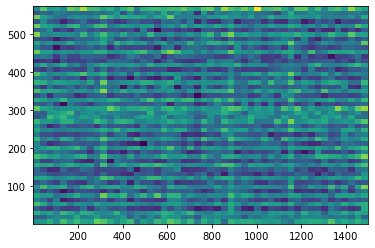

In [25]:
# view of asics
x = df['pX'].values
y = df['pY'].values

xZoom, yZoom =  1, 1

# plt.hist(x)
plt.hist2d(y,x,bins=(50,50), range=[[1,max(y)],[1,max(x)]])

print("min x:", min(x), "max: ", max(x))
print("min y:", min(y), "max: ", max(y))
# xvals = df['pX'].value_counts()
# print(xvals)

# fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
# # h = ax[0].hist2d(y, x, bins=[len(df['AsicY'].unique()), len(df['AsicX'].unique())])
# h = ax[0].hist2d(y, x, bins=[int(yMAX/yZoom), int(xMAX/xZoom)], range=[[0, ceil(yMAX/yZoom)], [0, ceil(xMAX/xZoom)]])
# ax[0].set_ylabel('AsicX')
# ax[0].set_xlabel("AsicY")
# fig.colorbar(h[3], ax=ax[0])

# countPixels = df['nPix'].value_counts()
# counts = countPixels.unique()
# maxCount = max(counts)
# ax[1].hist(countAsics, bins=maxCount, range=(0, maxCount))
# ax[1].set_ylabel("Number of Pixels")
# ax[1].set_xlabel("Pixel Hits")
# plt.tight_layout()
# plt.savefig("PixelHits_hits.pdf")

17102  8     438376
 9     438373
 0     438371
 4     437830
 5     437776
 1     437772
 13    436841
 12    436279
 7     435708
 6     435481
 10    435034
 3     434729
 2     434430
 11    433934
 14    433313
 15    433141
-5      17102
Name: nPix, dtype: int64


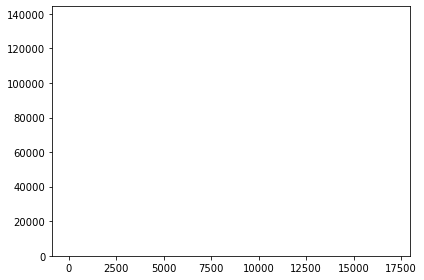

In [11]:
counts = df['PixN'].value_counts()
# counts = countPixels.unique()
maxCount = max(counts)
plt.hist(counts, bins=int(maxCount), range=(0, maxCount))
# plt.set_ylabel("Number of Pixels")
# plt.set_xlabel("Pixel Hits")
plt.tight_layout()
plt.savefig("PixelHits_long.pdf")
print(maxCount, countPixels)

### Identify source for 'bars' in center pattern

In [12]:
# cdf = df[df['Isotope'] != "K40"]

# x = cdf['AsicX'].values
# y = cdf['AsicY'].values

# fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
# h = ax[0].hist2d(y, x, bins=[int(yMAX/channelYdim/yZoom), int(xMAX/channelXdim/xZoom)], range=[[0, ceil(yMAX/channelYdim/yZoom)], [0, ceil(xMAX/channelXdim/xZoom)]])
# ax[0].set_ylabel('AsicX')
# ax[0].set_xlabel("AsicY")
# fig.colorbar(h[3], ax=ax[0])

# countAsics = cdf['AsicN'].value_counts()
# counts = countAsics.unique()
# maxCount = max(counts)
# ax[1].hist(countAsics, bins=maxCount, range=(0, maxCount))
# ax[1].set_ylabel("Number of ASICs")
# ax[1].set_xlabel("Asic Hits")
# plt.tight_layout()
# plt.savefig("AsicHits_long.pdf")

## Visualize the source of these resets from the isotope causing them

In [13]:
# # view of asics
# x = df['AsicX'].values
# y = df['AsicY'].values

# xZoom, yZoom = 1, 1

# isotopes = df['Isotope'].unique()

# stack_data = []
# for iso in isotopes:
#     data = df[df['Isotope'] == iso]['AsicN'].value_counts()
#     stack_data.append(data)
    
    
# fig, ax = plt.subplots(1, 2, figsize =(yMAX/scale*1.5, xMAX/scale), gridspec_kw={'width_ratios': [3, 1]})
# h = ax[0].hist2d(y, x, bins=[int(yMAX/channelYdim/yZoom), int(xMAX/channelXdim/xZoom)], range=[[0, ceil(yMAX/channelYdim/yZoom)], [0, ceil(xMAX/channelXdim/xZoom)]])
# ax[0].set_ylabel('AsicX')
# ax[0].set_xlabel("AsicY")
# fig.colorbar(h[3], ax=ax[0])

# # ax[1].hist(countAsics, bins=len(counts), log=True, range=(0, maxCount))
# ax[1].hist(stack_data, bins=60, range=(0, 60), histtype='bar', stacked=True, log=False, label=isotopes)
# ax[1].set_ylabel("Number of ASICs")
# ax[1].set_xlabel("Asic Hits")
# plt.legend(loc="upper right")
# plt.tight_layout()
# plt.savefig("AsicHits_isotope_long.pdf")